# Outlier Detection and Removal using Z-score Method


### Restriction: Data is normally distributed or close to the normal distribution

### Concept: Values beyond 3 times standard deviation from the mean in both left and right side of the distribution are identified as outliers. The detected outliers are either trimmed (removed) or capped.

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [78]:
df = pd.read_csv('placement.csv')

In [79]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


In [80]:
df.shape

(1000, 3)

## Visualizing the distributions of cgpa and placement_exam_marks columns

C:\Users\DELL\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\DELL\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='placement_exam_marks', ylabel='Density'>

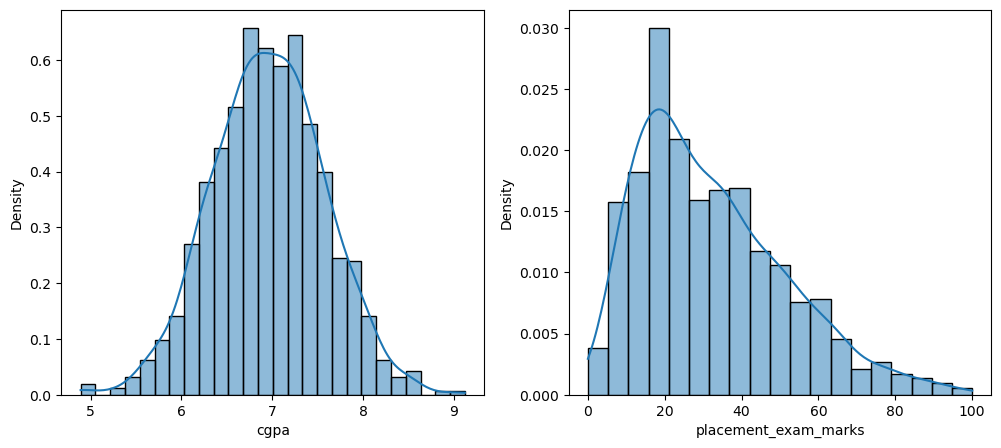

In [81]:
fig ,(ax1, ax2) = plt.subplots(1, 2,figsize=(12,5))

sns.histplot(df['cgpa'], ax=ax1, kde=True, stat='density')
sns.histplot(df['placement_exam_marks'], ax=ax2, kde=True, stat='density')


In [82]:
df['cgpa'].skew(), df['placement_exam_marks'].skew()

(-0.014529938929314918, 0.8356419499466834)

#### Outlier removal using z-score (or beyond 3 SD of the mean on either side of the distribution) is suitable for cgpa column as it very close to the normal distribution, however placement_exam_marks if skewed to the right hence may not be suitable.

# Trimming 

## 1. First approach

In [83]:
df['cgpa'].describe()

count    1000.000000
mean        6.961240
std         0.615898
min         4.890000
25%         6.550000
50%         6.960000
75%         7.370000
max         9.120000
Name: cgpa, dtype: float64

In [84]:
# determining boundary
upper = df['cgpa'].mean() + 3*df['cgpa'].std()
lower = df['cgpa'].mean() - 3*df['cgpa'].std()

In [85]:
upper, lower

(8.808933625397168, 5.113546374602832)

In [86]:
#Identifying Outliers 
df[(df['cgpa'] < lower) | (df['cgpa'] > upper)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


#### We can see that there are 5 rows with outliers in cgpa column 

### Trimming outliers

In [87]:
new_df = df[(df['cgpa'] > lower) & (df['cgpa'] < upper)]
new_df.shape

(995, 3)

In [88]:
new_df['cgpa'].describe()

count    995.000000
mean       6.963357
std        0.600082
min        5.230000
25%        6.550000
50%        6.960000
75%        7.365000
max        8.620000
Name: cgpa, dtype: float64

## 2. Second Approach

In [89]:
# calculating z-score
df['z-score_cgpa'] = (df['cgpa'] - df['cgpa'].mean()) / df['cgpa'].std()

In [90]:
df.head()

,cgpa,placement_exam_marks,placed,z-score_cgpa
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371


In [91]:
# Identifying outliers
df[(df['z-score_cgpa'] > 3) | (df['z-score_cgpa'] < -3)]


,cgpa,placement_exam_marks,placed,z-score_cgpa
485,4.92,44.0,1,-3.314251
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


### Trimming Outliers

In [92]:
df2 = df[(df['z-score_cgpa'] > -3) & (df['z-score_cgpa'] < 3) ]
df2.shape

(995, 4)

# Capping 

In [93]:
upper_limit = df['cgpa'].mean() + 3 * df['cgpa'].std()
lower_limit = df['cgpa'].mean() - 3 * df['cgpa'].std()

In [94]:
upper_limit, lower_limit

(8.808933625397168, 5.113546374602832)

In [95]:
#before capping
df['cgpa'].describe()

count    1000.000000
mean        6.961240
std         0.615898
min         4.890000
25%         6.550000
50%         6.960000
75%         7.370000
max         9.120000
Name: cgpa, dtype: float64

In [96]:
df['cgpa'] = np.where(
    df['cgpa'] > upper_limit, # condition
    upper_limit, # if condition is True
    np.where(
        df['cgpa'] < lower_limit, #condition2
        lower_limit, #if condition2 is True
        df['cgpa'] # if condition2 is False
        )
    )

In [97]:
#after capping
df['cgpa'].describe()

count    1000.000000
mean        6.961499
std         0.612688
min         5.113546
25%         6.550000
50%         6.960000
75%         7.370000
max         8.808934
Name: cgpa, dtype: float64